# A Rota da Neuromante - Análise do problema, discussão de resultados e conclusão

###### Notebook produzido por Ana Carolina Sayumi Imahata Alves

## Introdução

### Sobre este notebook

O objetivo deste notebook é introduzir a atividade a ser feita, bem como a motivação por trás da escolha do dataset, análise de resultados e conclusão.

### Sobre a atividade

Para essa atividade iremos construir uma rede neural do tipo MLP de classificação binária com otimização de hiperparâmetros por `optuna`. Como adicionais, também faremos uma MLP com hiperparâmetros arbitrários e duas florestas aleatórias: uma com otimização e outra sem, para comparação de resultados. Cada modelo terá seu próprio notebook.

### Motivação

"Você acorda de manhã, sem se sentir descansado, e não sabe que dia da semana é aquele, ou qual data, qual é o mês ou mesmo qual é o ano. Você não se pembra do que planejou para o dia. Você se levanta e veste um dos três outfits que usa regularmente, ignorando todas as outras roupas no seu closet. Você vai para a cozinha para fazer café, mas não se lembra de onde ele está. Você dá ração aos gatos. Ou será que já fez isso? Você tira as louças do lava-louças, mas não tem certeza de onde colocá-las.

[...]

Quando o filme acaba você se arruma para ir dormir. Você se esquece de escovar os dentes. Uma vez na cama, leva um longo tempo até que caia no sono. Uma vez dormindo você acorda em algumas horas e de novo mais tarde.

Você acorda de manhã, sem se sentir descansado, e não sabe que dia da semana é aquele, ou qual data, qual é o mês ou mesmo qual é o ano." [1]

O relato acima foi feito por Deborah Gould, uma senhora diagnosticada com Alzheimer em 2016. Ele evidencia quão importante é a memória para nós humanos. Sem ela nos deslocalizamos no tempo e no espaço. Fica difícil saber o que fazer a seguir na falta da informação sobre o que foi feito anteriormente. Como haveriam ciências? Como haveria qualquer conhecimento independente de impulsos, instinto? Será que chamaríamos isso de conhecimento? Será que sequer haveriam palavras?

A memória é um grande constituinte do que chamamos de humanidade e, sem ela, certamente as estruturas que temos hoje não existiriam. Dito isso, há uma grande sensibilidade ao tratarmos da doença de Alzheimer e um interesse crescente em entender como identificar e tratar essa doença. De acordo com os registros da PubMed, parte da National Library of Medicine - National Center for Biotechnology Information (NCBI) ao buscar por "Alzheimer's disease"[2], o interesse pela doença de alzheimer cresceu em quase 2.000% desde a década de 60. Segue abaixo o gráfico que apresenta esses dados.

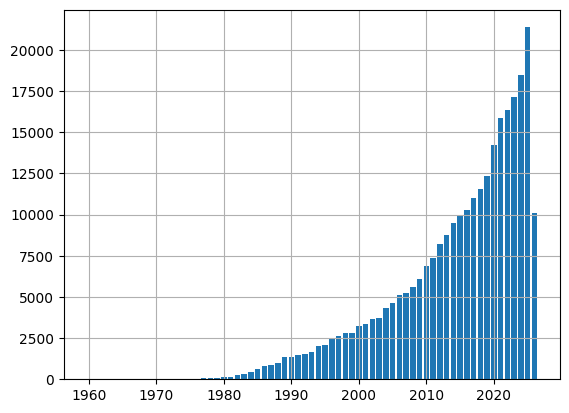

## Sobre os dados

Uma vez motivados, o _dataset_ que utilizaremos para essa atividade é uma versão processada dos dados clínicos apresentados por Craig-Schapiro et al. (2011) [3], contendo informações de 333 indivíduos, incluindo pacientes com comprometimento cognitivo leve e indivíduos cognitivamente saudáveis. Os dados incluem 131 variáveis, como características demográficas, medições de Aβ, Tau, pTau e 124 biomarcadores exploratórios obtidos a partir de amostras de líquido cefalorraquidiano (CSF). Na versão disponibilizada, os participantes foram agrupados em duas classes: "Impaired" e "Control" (nosso target).

Os dados processados, diaponibilizados por Kuhn et al. (2013) [4], podem ser encontrados e baixados pesquisando por "Alzheimer" no site das referências [5]. Neste site o nome do arquivo é "ad_data", com título "Alzheimer's disease data".

Segue abaixo uma vizualização inicial do DataFrame.

In [4]:
import pandas as pd

#Leitura do arquivo
arquivo = "Dataset_Alzheimers_sep.xlsx"
df = pd.read_excel(arquivo)

df

,rownames,ACE_CD143_Angiotensin_Converti,ACTH_Adrenocorticotropic_Hormon,AXL,Adiponectin,Alpha_1_Antichymotrypsin,Alpha_1_Antitrypsin,Alpha_1_Microglobulin,Alpha_2_Macroglobulin,Angiopoietin_2_ANG_2,...,VEGF,Vitronectin,von_Willebrand_Factor,age,tau,p_tau,Ab_42,male,Genotype,Class
0,1,2.003100,-1.386294,1.098387,-5.360193,1.740466,-12.631361,-2.577022,-72.650290,1.064711,...,22.034564,-0.040822,-3.146555,0.987624,6.297754,4.348108,12.019678,0,E3E3,Control
1,2,1.561856,-1.386294,0.683282,-5.020686,1.458615,-11.909882,-3.244194,-154.612278,0.741937,...,18.601843,-0.385662,-3.863233,0.986150,6.659294,4.859967,11.015759,0,E3E4,Control
2,3,1.520660,-1.714798,-0.145276,-5.809143,1.193922,-13.642963,-2.882404,-136.529178,0.832909,...,17.476191,-0.223144,-3.540459,0.986667,6.270988,4.400247,12.302271,1,E3E4,Control
3,4,1.680826,-1.609438,0.683282,-5.115996,1.280934,-15.523564,-3.170086,-98.361752,0.916291,...,17.545595,-0.653926,-3.863233,0.986702,6.152733,4.494886,12.398138,0,E3E4,Control
4,5,2.400931,-0.967584,0.190890,-4.779524,2.128232,-11.133063,-2.343407,-144.944601,0.955511,...,20.778602,0.166216,-3.816713,0.987163,6.623707,4.524589,11.024109,0,E3E3,Control
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,329,1.719055,-1.660731,0.828427,-5.449140,1.098612,-16.321511,-3.324236,-160.010404,0.955511,...,17.517898,-0.446287,-3.729701,0.983687,6.132899,4.430662,11.913409,0,E3E3,Control
329,330,1.391905,-1.514128,-0.145276,-4.906275,1.609438,-11.838035,-2.120264,-154.612278,0.405465,...,15.618049,0.205439,-4.509860,0.984351,4.805741,3.357803,12.878940,1,E3E4,Control
330,331,1.001198,-1.347074,-0.010025,-4.509860,1.193922,-14.406260,-3.170086,-179.087488,-0.248461,...,14.543388,-0.478036,-4.509860,0.986877,5.551835,3.768614,9.508593,0,E3E3,Control
331,332,0.946207,-1.771957,0.000000,-5.521461,1.704748,-12.543721,-3.036554,-132.715082,0.405465,...,16.363273,0.182322,-4.342806,0.984227,4.595120,3.218876,13.072866,1,E3E3,Control


Uma vez com o dataframe temos uma noção do que precisará ser feito. Primeiro, a coluna rownames deverá ser removida. Tembém será preciso passar um encoder em dados categóricos (mas não faremos isso para o target, pois cada modelo recebe os dados de uma maneira) e verificar se estamos falando de um dataset desbalanceado ou não.

Os tratamentos serão feitos nos notebooks de cada modelo, no entanto, ainda é preciso que verifiquemos o balanceamento do dataset. Para datasets envolvendo doenças, é muito comum que encontremos forte desbalanceamento, por essa razão, isso será verificado.

In [21]:
target = pd.unique(df["Class"])
classes = df["Class"].value_counts()
print(classes)

razão = classes.iloc[0]/classes.iloc[-1]

print("----------------")
print(f"A razão entre as categorias é de {round(razão, 1)}:1")

p1 = (classes.iloc[0]/333)*100
p2 = (classes.iloc[-1]/333)*100

print("----------------")
print(f"A distribuição de porcentagens é de {round(p1, 1)}% e {round(p2, 1)}%")

Class
Control     242
Impaired     91
Name: count, dtype: int64
----------------
A razão entre as categorias é de 2.7:1
----------------
A distribuição de porcentagens é de 72.7% e 27.3%


Não há uma definição exata do que são dados desbalanceados ou não, mas percebemos que, para o dataset escolhido, há um desbalanceamento leve. Dessa forma, apenas usaremos uma estratégia de estratificação dos dados no momento de divisão entre treino, validação e teste, para garantir que temos ambos os exemplos em todos os subconjuntos de dados. Como falamos de um problema de classificação, iremos olhar para a métrica de precisão e a matriz de confusão gerada, mais que sua acurácia, que pode ser enganosa.

Feita essa análise, iremos seguir então para a construção de nossos modelos, nos outros notebooks (também disponibilizados no GitHub).

## Resultados

#### F1-score

os F1-scores médios entre classes foram:

- MLP sem otimização: 0.42
- MLP com otimização: 0.73
- Random Forest sem otimização: 0.89
- Random Forest com otimização: 0.76

Poderíamos inferir, a partir apenas desses dados, que as florestas aleatória apresentaram melhor desempenho, mas será que podemos considerar apenas o valor médio? A resposta curta é não, especialmente porque temos um problema no qual a identificação de "Impaired"'s é bastante relevante. Entretanto não podemos descartar totalmente esses dados pois, imagine-se recebendo um diagnóstico errado de desenvolvimento de uma doença neurodegenerativa? É preciso balancear os acertos dos modelos.

#### Matriz de confusão

Abaixo, seguem as matrizes de confusão de cada modelo. Também foram calculados os acertos absolutos de cada modelo.

##### MLP sem otimização

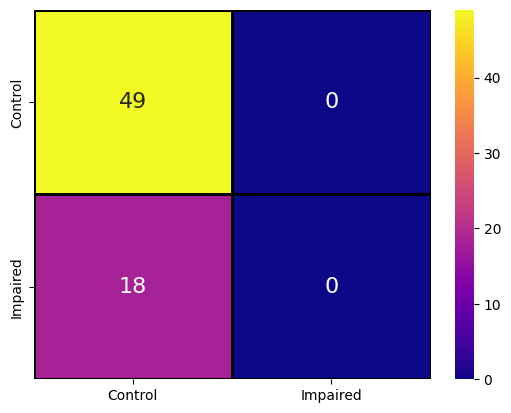

Acerto absoluto: 49/67

##### MLP com otimização

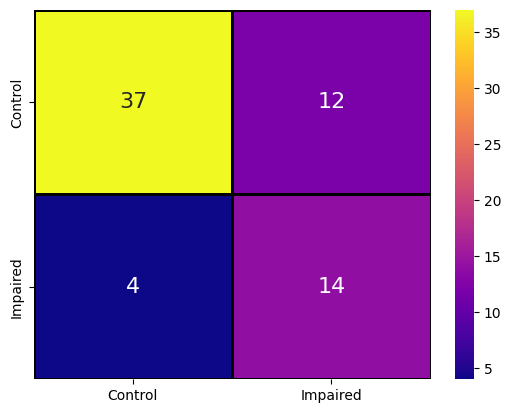

Acerto absoluto: 51/67

##### Random Forest sem otimização

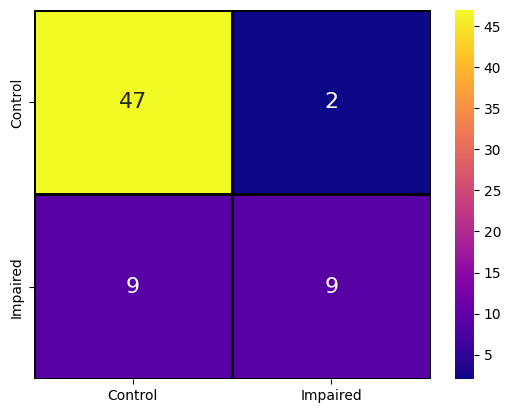

Acerto absoluto: 56/67

##### Random Forest com otimização

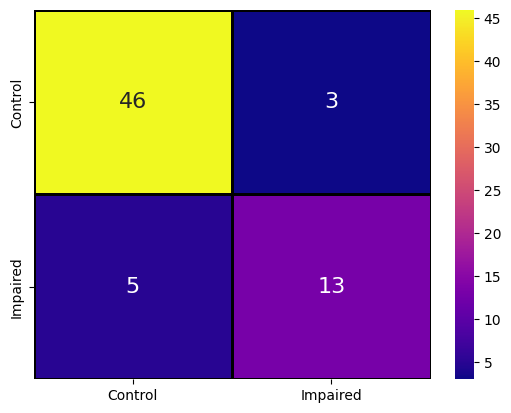

Acerto absoluto: 59/67

#### Análise de ambos os resultados

Em acertos absolutos e F1-scores as florestas aleatórias foram melhores, entretanto a MLP otimizada foi quem apresentou o melhor desempenho na classificação de "Impaired"s. Isso nos leva a ponderação de qual modelo é melhor para cada finalidade.

## Conclusão

Muito embora a otimização de uma rede neural leve mais tempo para rodar, podemos notar que, neste caso, seu desempenho foi ligeiramente melhor que o de uma floresta aleatória otimizada. Isso pode levantar o questionamento: quando vale a pena usar uma rede neural do tipo MLP otimizada e não outro modelo? Isso vai depender de quanto tempo e processamento estão à sua disposição e do quão relevante ou necessário é garantir que seu modelo compreenda as nuances de dados não linearmente relacionados e os preveja corretamente.


Vale ressaltar que o processo de otimização de uma rede neural certamente não é trivial, entretanto é uma ótima experiência de desenvolvimento acadêmico.

## Referências

[1] Disponível em: https://www.alzsd.org/words-like-alzheimers/

[2] Os dados utilizados podem ser obtidos no seguinte link: https://pubmed.ncbi.nlm.nih.gov/?term=alzheimer%27s+disease

[3] Craig-Schapiro R, Kuhn M, Xiong C, Pickering EH, Liu J, Misko TP, et al. (2011) Multiplexed Immunoassay Panel Identifies Novel CSF Biomarkers for Alzheimer's Disease Diagnosis and Prognosis. PLoS ONE 6(4): e18850. https://doi.org/10.1371/journal.pone.0018850

[4] Kuhn, M., & Johnson, K. (2013). Applied Predictive Modeling. Springer. Dataset "ad_data" do pacote "modeldata".

[5] Disponível em: https://vincentarelbundock.github.io/Rdatasets/articles/data.html